# Verificación de la grilla de $r_d$ (CLASS vainilla)

`BAO.r_drag_grid(Omega_m, H_0, wb)` interpola $r_d$ desde una grilla en $(\omega_m=\Omega_m h^2,\ \omega_b,\ h)$ calculada con CLASS vainilla 3.3.4 (`fr_mcmc/source/rd_grid/make_rd_grid.py`). La interpolación es un spline cúbico en $\ln r_d$.

Configuración (igual en la grilla y en el cálculo directo `BAO.r_drag_class`): ΛCDM, un neutrino masivo con $m_\nu=0.06$ eV, $N_{ur}=2.0308$ ($N_{eff}=3.044$), precisión por defecto de CLASS (HyRec). $\omega_m$ incluye los neutrinos.

Este notebook compara la grilla contra CLASS **calculado directamente** en:
1. los nodos de la grilla;
2. miles de puntos al azar y en los centros de las celdas (el peor caso para la interpolación);
3. los bordes del rango válido;
4. parámetros físicos $(\Omega_m, H_0)$, pasando por la conversión de `r_drag_grid`;
5. el $\chi^2$ de DESI DR2 y BAO full.

Todas las diferencias están en %. Como referencia de escala: CLASS contra CAMB difiere ~0.01 %, y DESI DR2 mide $D/r_d$ al ~0.3–1 %.

In [1]:
import os, sys, time, types, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from multiprocessing import Pool
warnings.filterwarnings('ignore')

# classy de CLASS vainilla (compilado en code/class_public-3.3.4/classy_py310)
CLASSY_PATH = os.environ.get('CLASSY_PATH', os.path.expanduser('~/Documents/PhD/code/class_public-3.3.4/classy_py310'))
sys.path.insert(0, CLASSY_PATH)
import classy
print('classy:', classy.__file__)
assert 'class_public' in classy.__file__, 'No es el classy de CLASS vainilla'

import git
path_git = git.Repo('.', search_parent_directories=True).working_tree_dir
sys.path.append(os.path.join(path_git, 'fr_mcmc', 'utils'))
from BAO import r_drag_grid, r_drag_class, _load_rd_grid

g = np.load(os.path.join(path_git, 'fr_mcmc', 'source', 'rd_grid', 'rd_grid_class.npz'))
for k in ['omega_m', 'omega_b', 'h']:
    a = g[k]; v = g['valid_' + k]
    print(f'{k:8s}: {len(a)} nodos, paso {a[1]-a[0]:.5g}, rango válido [{v[0]}, {v[1]}] (+2 nodos de margen a cada lado)')
print('m_ncdm =', float(g['m_ncdm']), ' N_ur =', float(g['N_ur']), ' generada con', str(g['classy_path']))

def rd_direct(p):
    '''CLASS directo con los mismos settings que la grilla. p = (omega_m, omega_b, h).'''
    wm, wb, h = p
    M = classy.Class()
    M.set({'h': h, 'omega_b': wb, 'omega_m': wm, 'N_ur': 2.0308, 'N_ncdm': 1, 'm_ncdm': 0.06, 'output': ''})
    M.compute(['thermodynamics']); r = M.rs_drag(); M.struct_cleanup(); M.empty()
    return r

def rd_interp(p):
    wm, wb, h = p
    return r_drag_grid(wm/h**2, 100*h, wb)

def compare(points, nproc=20):
    with Pool(nproc) as pool:
        direct = np.array(pool.map(rd_direct, points, chunksize=16))
    interp = np.array([rd_interp(p) for p in points])
    return 100*(interp/direct - 1)

def stats(name, d):
    a = np.abs(d)
    print(f'{name:45s} N={len(d):5d}   max |Δ| = {a.max():.2e} %   percentil 99 = {np.percentile(a, 99):.2e} %   mediana = {np.median(a):.2e} %')

valid = [g['valid_omega_m'], g['valid_omega_b'], g['valid_h']]
rng = np.random.default_rng(12345)

classy: /home/matias/Documents/PhD/code/class_public-3.3.4/classy_py310/classy/__init__.py


omega_m : 191 nodos, paso 0.0025, rango válido [0.035, 0.5] (+2 nodos de margen a cada lado)
omega_b : 33 nodos, paso 0.00025, rango válido [0.019, 0.026] (+2 nodos de margen a cada lado)
h       : 15 nodos, paso 0.05, rango válido [0.5, 1.0] (+2 nodos de margen a cada lado)
m_ncdm = 0.06  N_ur = 2.0308  generada con /home/matias/Documents/PhD/code/class_public-3.3.4/classy_py310/classy/__init__.py


## 1. Nodos de la grilla

Un spline interpolante pasa por los nodos, así que la diferencia debería estar al nivel del redondeo. Se usa una muestra de nodos dentro del rango válido y se **recalcula CLASS** en ellos (no se lee el valor guardado), así que también se verifica que la grilla guardada sea reproducible.

In [2]:
om_n = g['omega_m'][2:-2]; ob_n = g['omega_b'][2:-2]; h_n = g['h'][2:-2]
nodes = [(om_n[i], ob_n[j], h_n[k]) for i, j, k in zip(rng.integers(0, len(om_n), 400), rng.integers(0, len(ob_n), 400), rng.integers(0, len(h_n), 400))]
d_nodes = compare(nodes)
stats('Nodos (CLASS recalculado)', d_nodes)

Nodos (CLASS recalculado)                     N=  400   max |Δ| = 3.77e-13 %   percentil 99 = 3.55e-13 %   mediana = 1.33e-13 %


## 2. Puntos al azar y centros de celda

In [3]:
N = 3000
rand = np.column_stack([rng.uniform(*valid[0], N), rng.uniform(*valid[1], N), rng.uniform(*valid[2], N)])
d_rand = compare([tuple(p) for p in rand])
stats('Puntos al azar en el rango válido', d_rand)

# centros de celda: a mitad de camino entre nodos en las 3 direcciones (peor caso)
cen = []
for _ in range(1500):
    i = rng.integers(2, len(g['omega_m']) - 3); j = rng.integers(2, len(g['omega_b']) - 3); k = rng.integers(2, len(g['h']) - 3)
    cen.append(((g['omega_m'][i] + g['omega_m'][i+1])/2, (g['omega_b'][j] + g['omega_b'][j+1])/2, (g['h'][k] + g['h'][k+1])/2))
d_cen = compare(cen)
stats('Centros de celda', d_cen)

Puntos al azar en el rango válido             N= 3000   max |Δ| = 1.33e-02 %   percentil 99 = 1.85e-03 %   mediana = 1.00e-05 %


Centros de celda                              N= 1500   max |Δ| = 1.12e-02 %   percentil 99 = 2.89e-03 %   mediana = 1.33e-05 %


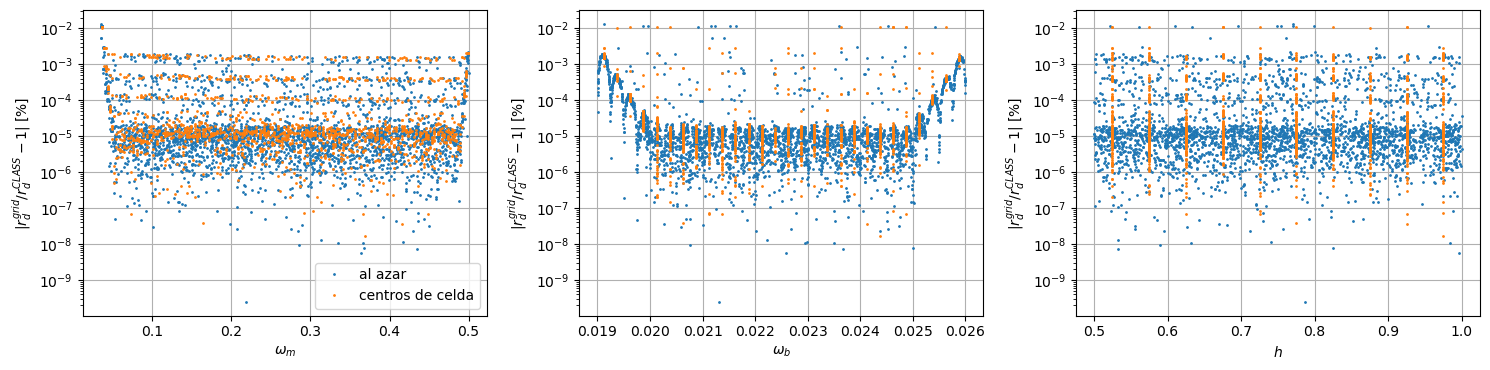

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, i, lab in zip(axs, range(3), [r'$\omega_m$', r'$\omega_b$', '$h$']):
    ax.semilogy(rand[:, i], np.abs(d_rand) + 1e-12, '.', ms=2, label='al azar')
    ax.semilogy(np.array(cen)[:, i], np.abs(d_cen) + 1e-12, '.', ms=2, label='centros de celda')
    ax.set_xlabel(lab); ax.set_ylabel(r'$|r_d^{grid}/r_d^{CLASS}-1|$ [%]'); ax.grid(True)
axs[0].legend(); plt.tight_layout()

## 3. Bordes del rango válido

Puntos sobre las caras y las esquinas del rango válido. El margen de 2 nodos a cada lado evita que el spline pierda precisión en los bordes.

In [5]:
edge = []
for _ in range(1000):
    p = [rng.uniform(*valid[0]), rng.uniform(*valid[1]), rng.uniform(*valid[2])]
    ax_ = rng.integers(0, 3); p[ax_] = valid[ax_][rng.integers(0, 2)]
    edge.append(tuple(p))
corners = [(a, b, c) for a in valid[0] for b in valid[1] for c in valid[2]]
d_edge = compare(edge + corners)
stats('Caras y esquinas del rango válido', d_edge)

Caras y esquinas del rango válido             N= 1008   max |Δ| = 1.11e-02 %   percentil 99 = 1.97e-03 %   mediana = 6.01e-06 %


## 4. Parámetros físicos: `r_drag_grid(Omega_m, H_0, wb)` contra `r_drag_class(Omega_m, H_0, wb)`

Se usan las funciones del código tal como las llama el $\chi^2$ (que convierten $\Omega_m, H_0 \to \omega_m, h$), con $\omega_b = \omega_b^{BBN} = 0.02218$ y en el rango de los priors.

In [6]:
from constants import WB_BBN
phys = np.column_stack([rng.uniform(0.1, 0.6, 1000), rng.uniform(50, 100, 1000)])
phys = phys[(phys[:, 0]*(phys[:, 1]/100)**2 >= valid[0][0]) & (phys[:, 0]*(phys[:, 1]/100)**2 <= valid[0][1])]
d_phys = np.array([100*(r_drag_grid(om, H0, WB_BBN)/r_drag_class(om, H0, WB_BBN) - 1) for om, H0 in phys])
stats('r_drag_grid vs r_drag_class (Ωm, H0, ω_b=BBN)', d_phys)

# Fuera del rango: tiene que dar error (el chi2 lo convierte en +inf)
for om, H0, wb in [(0.05, 55, WB_BBN), (0.3, 70, 0.03), (0.3, 110, WB_BBN)]:
    try:
        r_drag_grid(om, H0, wb); print('NO dio error:', om, H0, wb)
    except ValueError as e:
        print('Fuera de rango -> ValueError:', e)

r_drag_grid vs r_drag_class (Ωm, H0, ω_b=BBN) N=  976   max |Δ| = 1.16e-02 %   percentil 99 = 2.92e-04 %   mediana = 8.81e-06 %
Fuera de rango -> ValueError: omega_m=0.01513 outside of the r_d grid [0.035, 0.5]
Fuera de rango -> ValueError: omega_b=0.03000 outside of the r_d grid [0.019, 0.026]
Fuera de rango -> ValueError: h=1.10000 outside of the r_d grid [0.5, 1.0]


## 5. Dependencia con $h$ y comparación con CAMB (control)

A $\omega_m$ y $\omega_b$ fijos, $r_d$ casi no depende de $h$ (solo a través de $\Omega_\Lambda$, despreciable antes de la recombinación). CAMB es un código independiente: se espera un acuerdo de ~0.01 %.

In [7]:
hs = np.linspace(*valid[2], 11)
r_h = np.array([rd_direct((0.14, 0.02218, h)) for h in hs])
print(f'variación de r_d con h (omega_m=0.14, omega_b=0.02218): {100*(r_h.max()/r_h.min() - 1):.1e} %')
try:
    import camb
    for wm, h in [(0.10, 0.6), (0.14, 0.7), (0.20, 0.8)]:
        p = camb.set_params(H0=100*h, ombh2=0.02218, omch2=wm - 0.02218 - 0.06/93.14, mnu=0.06, nnu=3.044)
        rc = camb.get_background(p).get_derived_params()['rdrag']
        print(f'omega_m={wm}, h={h}:  grilla {rd_interp((wm, 0.02218, h)):.4f}   CLASS {rd_direct((wm, 0.02218, h)):.4f}   CAMB {rc:.4f}   grilla vs CAMB {100*(rd_interp((wm,0.02218,h))/rc-1):+.3f} %')
except ImportError:
    print('CAMB no instalado')

variación de r_d con h (omega_m=0.14, omega_b=0.02218): 5.4e-05 %
omega_m=0.1, h=0.6:  grilla 160.4747   CLASS 160.4747   CAMB 160.4538   grilla vs CAMB +0.013 %


omega_m=0.14, h=0.7:  grilla 148.0728   CLASS 148.0729   CAMB 148.0669   grilla vs CAMB +0.004 %
omega_m=0.2, h=0.8:  grilla 134.4080   CLASS 134.4080   CAMB 134.4219   grilla vs CAMB -0.010 %


## 6. Impacto en el $\chi^2$ (DESI DR2 y BAO full)

Se compara el $\chi^2$ del código con $r_d$ de la grilla contra el mismo $\chi^2$ con $r_d$ de CLASS directo.

In [8]:
try:
    import torch
except ImportError:  # chi_square importa ML (torch); la rama ML no se usa acá
    ml = types.ModuleType('ML'); ml.H_ML = None; ml.ML_limits = lambda m: (0, 0, 0, 0)
    sys.modules['ML'] = ml
import chi_square as cs
from data import read_data_DESI, read_data_BAO_full
S = os.path.join(path_git, 'fr_mcmc', 'source')
os.chdir(os.path.join(S, 'DESI')); ds_DESI = read_data_DESI('DESI_DR2_dm_dh.txt', 'DESI_DR2_dv.txt')
os.chdir(os.path.join(S, 'BAO_legacy_2')); ds_BAOf = read_data_BAO_full('BAO_full_1.csv', 'BAO_full_2.csv')

rows = []
for om, H0 in [(0.25, 65), (0.2975, 68.5), (0.30, 70), (0.35, 73), (0.40, 80)]:
    for name, kw in [('DESI DR2', dict(dataset_DESI=ds_DESI)), ('BAO full', dict(dataset_BAO_full=ds_BAOf))]:
        cs.r_drag_grid = r_drag_grid
        c_grid = cs.params_to_chi2([0, 147, om, H0], None, index=4, model='LCDM', **kw)
        cs.r_drag_grid = r_drag_class
        c_dir = cs.params_to_chi2([0, 147, om, H0], None, index=4, model='LCDM', **kw)
        cs.r_drag_grid = r_drag_grid
        rows.append(dict(dataset=name, Om=om, H0=H0, chi2_grilla=c_grid, chi2_CLASS=c_dir, **{'|Δχ²|': abs(c_grid - c_dir), '|Δχ²| [%]': 100*abs(c_grid/c_dir - 1)}))
pd.set_option('display.float_format', lambda x: '%.4g' % x)
pd.DataFrame(rows)

,dataset,Om,H0,chi2_grilla,chi2_CLASS,|Δχ²|,|Δχ²| [%]
0,DESI DR2,0.25,65,129.5,129.5,0.0009092,0.0007021
1,BAO full,0.25,65,54.28,54.28,0.000319,0.0005877
2,DESI DR2,0.2975,68.5,10.28,10.28,1.1e-05,0.000107
3,BAO full,0.2975,68.5,10.87,10.87,5.373e-05,0.0004943
4,DESI DR2,0.3,70,23.24,23.24,0.0003835,0.00165
5,BAO full,0.3,70,20.66,20.66,0.0002232,0.001081
6,DESI DR2,0.35,73,113.6,113.6,6.994e-06,6.157e-06
7,BAO full,0.35,73,66.38,66.38,3.393e-06,5.111e-06
8,DESI DR2,0.4,80,475.5,475.5,0.001646,0.0003462
9,BAO full,0.4,80,234.9,234.9,0.0007364,0.0003135


## 7. Tiempo por llamada

In [9]:
t = time.time()
for _ in range(2000): r_drag_grid(0.3, 70, 0.02218)
t_grid = (time.time() - t)/2000
t = time.time()
for _ in range(20): r_drag_class(0.3, 70, 0.02218)
t_class = (time.time() - t)/20
print(f'grilla: {1e6*t_grid:.0f} µs    CLASS directo: {1e3*t_class:.0f} ms    (x{t_class/t_grid:.0f})')

grilla: 21 µs    CLASS directo: 79 ms    (x3671)


## Resumen

In [10]:
summary = pd.DataFrame([dict(prueba=n, N=len(d), **{'max |Δ| [%]': np.max(np.abs(d)), 'percentil 99 [%]': np.percentile(np.abs(d), 99)})
                        for n, d in [('Nodos', d_nodes), ('Al azar', d_rand), ('Centros de celda', d_cen), ('Bordes y esquinas', d_edge), ('(Ωm, H0) físicos', d_phys)]])
pd.set_option('display.float_format', lambda x: '%.2e' % x)
summary

,prueba,N,max |Δ| [%],percentil 99 [%]
0,Nodos,400,3.77e-13,3.55e-13
1,Al azar,3000,1.33e-02,1.85e-03
2,Centros de celda,1500,1.12e-02,2.89e-03
3,Bordes y esquinas,1008,1.11e-02,1.97e-03
4,"(Ωm, H0) físicos",976,1.16e-02,2.92e-04
